In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
load_path = Path("../../data/combined/done_week_45")
save_path = Path("../../data/combined")

In [3]:
listing = pd.read_parquet(load_path/"listing.parquet")

In [4]:
listing.columns

Index(['OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'AssociationFeeFrequency', 'CountyOrParish', 'ParkingTotal',
       'PropertySubType', 'YearBuilt', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'StateOrProvince', 'FireplaceYN', 'Levels',
       'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'PostalCode', 'AssociationFee', 'PurchaseContractDate',
       'ListingContractDate', 'ContractStatusChangeDate', 'rate_30yr_fixed',
       'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName',
       'listing_after_close_flag', 'purchase_after_close_flag',
       'geographic_error'],
      dtype='str')

In [5]:
fe_listing = listing.copy()

fe_listing["PriceRatio"] = np.where(
    fe_listing["OriginalListPrice"] > 0,
    fe_listing["ClosePrice"] / fe_listing["OriginalListPrice"],
    np.nan)
fe_listing["PricePerSqFt"] = np.where(
    fe_listing["LivingArea"] > 0,
    fe_listing["ClosePrice"] / fe_listing["LivingArea"],
    np.nan)

fe_listing["Year"] = fe_listing["CloseDate"].dt.year
fe_listing["Month"] = fe_listing["CloseDate"].dt.month
fe_listing["Year"] = fe_listing["Year"].astype('Int64')
fe_listing["Month"] = fe_listing["Month"].astype('Int64')
fe_listing["YrMo"] = fe_listing["Year"].astype(str) + "-" + fe_listing["Month"].astype(str)

fe_listing["ListingToContractDays"] = (fe_listing["PurchaseContractDate"] - fe_listing["ListingContractDate"]).dt.days
fe_listing["ContractToCloseDays"] = (fe_listing["CloseDate"] - fe_listing["PurchaseContractDate"]).dt.days
fe_listing["ListingToContractDays"] = fe_listing["ListingToContractDays"].astype('Int64')
fe_listing["ContractToCloseDays"] = fe_listing["ContractToCloseDays"].astype('Int64')

In [6]:
fe_listing[fe_listing["ClosePrice"].notna()]

,OriginalListPrice,CloseDate,ClosePrice,Latitude,Longitude,PropertyType,LivingArea,ListPrice,DaysOnMarket,AssociationFeeFrequency,...,listing_after_close_flag,purchase_after_close_flag,geographic_error,PriceRatio,PricePerSqFt,Year,Month,YrMo,ListingToContractDays,ContractToCloseDays
7,1249888.0,2024-05-01,1262555.0,33.477414,-117.664879,Residential,1899.0,1249888.0,0,Monthly,...,False,False,False,1.010135,664.852554,2024,5,2024-5,20,73
12,650000.0,2024-03-15,650000.0,35.508840,-120.690614,Residential,1400.0,650000.0,0,None,...,False,False,False,1.000000,464.285714,2024,3,2024-3,10,43
15,1025000.0,2024-05-02,962500.0,33.812886,-118.097004,Residential,1130.0,1025000.0,0,None,...,False,False,False,0.939024,851.769912,2024,5,2024-5,104,2
17,725000.0,2024-04-30,725000.0,33.740706,-117.888816,Residential,1250.0,725000.0,0,None,...,False,False,False,1.000000,580.000000,2024,4,2024-4,18,81
30,730000.0,2024-04-09,730000.0,NaN,NaN,Residential,1266.0,730000.0,35,None,...,False,False,True,1.000000,576.619273,2024,4,2024-4,35,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519791,2384000.0,2026-05-01,2650000.0,37.817147,-121.980675,Residential,2696.0,2384000.0,8,Quarterly,...,False,False,False,1.111577,982.937685,2026,5,2026-5,8,15
519798,1695000.0,2026-05-06,1827000.0,37.671712,-121.759595,Residential,2310.0,1695000.0,14,Monthly,...,False,False,False,1.077876,790.909091,2026,5,2026-5,14,21
519809,1100000.0,2026-05-05,1050000.0,33.195432,-117.218856,Residential,1659.0,1100000.0,16,None,...,False,False,False,0.954545,632.911392,2026,5,2026-5,0,30
519818,1278000.0,2026-04-27,1320000.0,37.953455,-122.002616,Residential,3035.0,1278000.0,3,None,...,False,False,False,1.032864,434.925865,2026,4,2026-4,3,14


<Axes: ylabel='PropertySubType'>

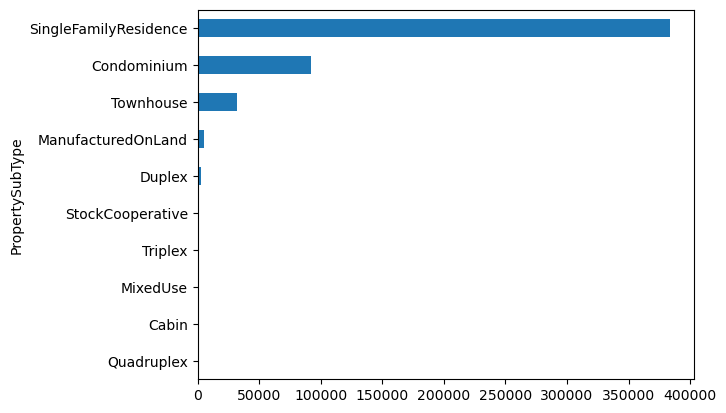

In [7]:
fe_listing["PropertySubType"].value_counts().head(10).sort_values().plot.barh()

<Axes: ylabel='CountyOrParish'>

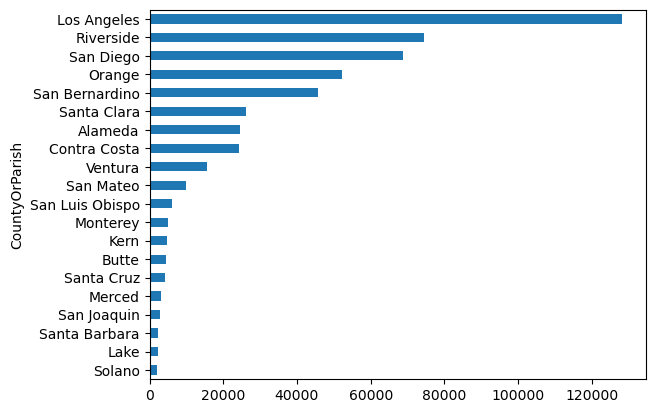

In [8]:
fe_listing["CountyOrParish"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='MLSAreaMajor'>

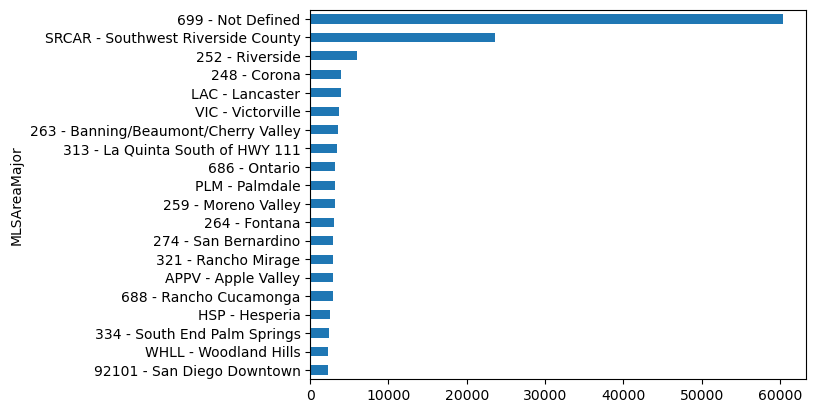

In [9]:
fe_listing["MLSAreaMajor"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='ListOfficeName'>

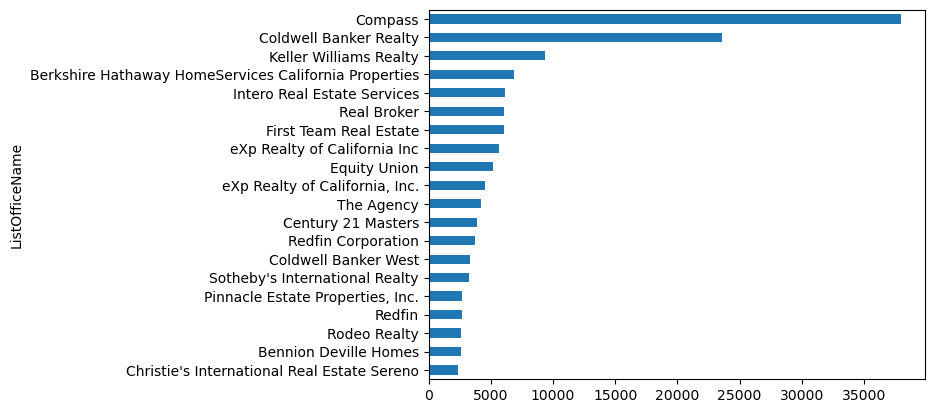

In [10]:
fe_listing["ListOfficeName"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='BuyerOfficeName'>

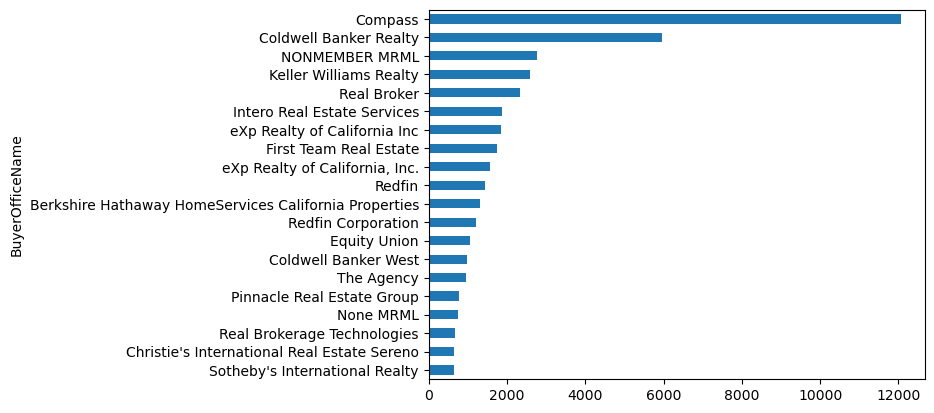

In [11]:
fe_listing["BuyerOfficeName"].value_counts().head(20).sort_values().plot.barh()

In [12]:
summary_by_PropertySubType = (
    fe_listing
    .groupby("PropertySubType")
    .agg(
        listing_count=("PropertySubType", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_PropertySubType.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
PropertySubType,,,,,,,,
SingleFamilyResidence,383689,1.320453e+06,950000.0,655.544014,46.515707,18.449731,22.250978,26.545141
Condominium,92292,8.699770e+05,648000.0,691.846078,29.322856,20.963128,25.755312,26.166928
Townhouse,32295,1.002148e+06,815000.0,673.065945,1.484331,19.061217,22.298323,27.1875
ManufacturedOnLand,4783,8.546678e+05,359400.0,507.656217,2.084420,20.220573,28.497901,33.374439
Duplex,2789,1.332145e+06,989250.0,707.196100,0.993141,18.592327,24.189906,30.750842
StockCooperative,1274,4.041880e+05,385000.0,407.029972,0.983026,19.174254,25.036075,44.645161
Triplex,489,1.431147e+06,1100000.0,586.917627,1.105687,20.764826,32.569444,38.161765
MixedUse,284,8.963435e+05,585000.0,463.278701,0.973330,23.123239,46.561404,24.310345
Cabin,278,3.932160e+05,292500.0,387.682523,0.918217,22.809353,37.179487,28.222222


In [13]:
summary_by_CountyOrParish = (
    fe_listing
    .groupby("CountyOrParish")
    .agg(
        listing_count=("CountyOrParish", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_CountyOrParish.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
CountyOrParish,,,,,,,,
Los Angeles,128143,1.315652e+06,925000.0,689.582748,29.689771,19.679569,24.046571,28.669402
Riverside,74413,7.350286e+05,610000.0,354.824661,110.620117,22.006786,29.530758,26.864662
San Diego,68690,1.309499e+06,905000.0,788.618063,1.288359,15.877944,21.38497,25.199025
Orange,52239,1.561635e+06,1200000.0,804.919036,101.333170,18.004441,23.665668,26.326628
San Bernardino,45606,6.663657e+05,560000.0,382.115225,94.323076,19.912095,26.414168,32.109469
Santa Clara,26284,1.985901e+06,1650000.0,1114.702721,1.064968,15.758598,12.700158,25.272021
Alameda,24652,1.343644e+06,1210000.0,756.449891,1.213471,16.345976,16.014797,23.338319
Contra Costa,24360,1.149001e+06,860000.0,578.185944,1.016587,17.114532,17.438062,23.396926
Ventura,15527,1.029112e+06,860000.0,544.246496,2.009094,21.181555,29.879276,21.423305


In [14]:
summary_by_BuyerOfficeName = (
    fe_listing
    .groupby("BuyerOfficeName")
    .agg(
        listing_count=("CountyOrParish", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_BuyerOfficeName.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
BuyerOfficeName,,,,,,,,
Compass,12066,1.809968e+06,1370000.0,880.580982,2.372533,18.824548,20.694387,22.318421
Coldwell Banker Realty,5959,1.635562e+06,1250000.0,819.746033,1.189807,20.008055,22.684794,23.048055
NONMEMBER MRML,2773,6.371495e+05,520000.0,360.422418,1.380998,29.177786,34.038226,32.1565
Keller Williams Realty,2586,1.319548e+06,869495.0,884.273941,1.470026,19.719644,22.990333,25.157011
Real Broker,2336,1.238094e+06,835000.0,805.775782,1.530228,23.241866,27.637414,26.070275
Intero Real Estate Services,1874,1.654216e+06,1403000.0,939.901610,1.046111,14.581110,14.151014,22.361994
eXp Realty of California Inc,1858,1.092949e+06,878000.0,645.193087,1.572749,23.934338,26.809473,25.835268
First Team Real Estate,1738,1.121310e+06,939500.0,631.786337,5.761678,21.082854,27.570276,26.577189
"eXp Realty of California, Inc.",1577,9.308007e+05,765000.0,564.752962,0.996408,22.315155,26.80279,26.45391


In [15]:
fe_listing.to_parquet(save_path/"listing_fe.parquet")